In [6]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from numpy.random import default_rng 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
rng = default_rng(seed=192553)

In [7]:
def custom_cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [8]:
def validate_cosine_similarity(a, b):
    return np.isclose(cosine_similarity(a.reshape(1, -1), b.reshape(1, -1)), custom_cosine_similarity(a, b))

In [9]:
a = rng.random(100000)
b = rng.random(100000)
print(np.isclose(cosine_similarity(a.reshape(1, -1), b.reshape(1, -1)), custom_cosine_similarity(a, b)))

[[ True]]


In [11]:
exc_stimuli = np.load("/src/project/data/experiment/exc_images_preprocessed.npy")

In [12]:
exc_stimuli.shape

(960, 36, 36)

In [13]:
np.min(exc_stimuli)

45.0

In [14]:
np.max(exc_stimuli)

215.5

In [4]:
raw_exc_stimuli = np.load("/src/project/data/experiment/exc_images.npy", allow_pickle=True)
raw_exc_stimuli = np.array([np.array(x) for x in raw_exc_stimuli])
raw_exc_stimuli.shape
raw_exc_stimuli_flat = raw_exc_stimuli.reshape(raw_exc_stimuli.shape[0], -1)
a = raw_exc_stimuli_flat[0]
b = raw_exc_stimuli_flat[1]

In [5]:
print(np.isclose(cosine_similarity(a.reshape(1, -1), b.reshape(1, -1)), custom_cosine_similarity(a, b)))

[[False]]


In [ ]:
normed_a = a / np.linalg.norm(a)
normed_b = b / np.linalg.norm(b)



In [39]:
raw_exc_stimuli = np.array([np.array(x) for x in raw_exc_stimuli])

In [40]:
raw_exc_stimuli.shape

(960, 144, 256)

In [41]:
raw_exc_stimuli_flat = raw_exc_stimuli.reshape(raw_exc_stimuli.shape[0], -1)

In [42]:
raw_exc_stimuli_flat.shape

(960, 36864)

In [43]:
first_sample = raw_exc_stimuli_flat[0]
second_sample = raw_exc_stimuli_flat[1]
print(first_sample.shape)
print(second_sample.shape)

(36864,)
(36864,)


In [44]:
print(np.isclose(cosine_similarity(first_sample.reshape(1, -1), second_sample.reshape(1, -1)), custom_cosine_similarity(first_sample, second_sample)))

[[False]]


In [45]:
cosine_similarity(first_sample.reshape(1, -1), second_sample.reshape(1, -1))

array([[0.99687581]])

In [46]:
custom_cosine_similarity(first_sample, second_sample)

1.4222524970185155e-08

<Axes: ylabel='Count'>

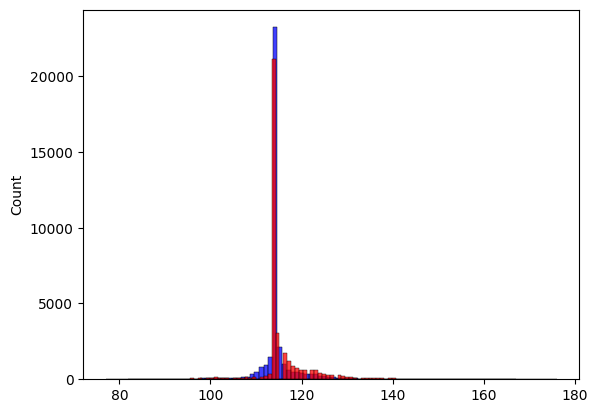

In [52]:
fig, ax = plt.subplots()
sns.histplot(first_sample, ax=ax, bins=100, color="blue")
sns.histplot(second_sample, ax=ax, bins=100, color="red")

In [49]:
second_sample

array([114, 114, 114, ..., 114, 114, 114], dtype=uint8)

In [54]:
# construct two orthogonal vectors
a = np.array([1, 0, 0])
b = np.array([0, 1, 0])
print(np.isclose(cosine_similarity(a.reshape(1, -1), b.reshape(1, -1)), custom_cosine_similarity(a, b)))

[[ True]]


In [58]:
scipy.sparse.issparse(raw_exc_stimuli_flat)

False

In [62]:
normalized_first_sample = first_sample / np.linalg.norm(first_sample)
normalized_second_sample = second_sample / np.linalg.norm(second_sample)
sklearn_cosine_similarity = cosine_similarity(normalized_first_sample.reshape(1, -1), normalized_second_sample.reshape(1, -1))[0, 0]
custom_cosine_similarity = custom_cosine_similarity(normalized_first_sample, normalized_second_sample)
print(np.isclose(sklearn_cosine_similarity, custom_cosine_similarity))

True
